# Notebook for Modeling 
## For Analyzing Bias after Vision Zero

In [22]:
# install packages if necessary
%pip install -r "requirements.txt"

# import relevant packages
import pandas as pd
import geopandas as gpd
import zipfile
from plotnine import *
import numpy as np
from data_functions import load_data

Note: you may need to restart the kernel to use updated packages.


### Load and process data
- Apply any necessary processing steps to the cleaned dataset
- This includes using one-hot encoding to convert categorical data into a binary array, which is necessary since there is no natural ordering between categories

In [23]:
file_path = "data/stops_clean.csv.zip"
stops_df = load_data(file_path)

Unzipped


In [24]:
# transform date and time variable to day of week and time 
stops_df['date'] = pd.to_datetime(stops_df['date'])
stops_df['day_of_week'] = stops_df['date'].dt.day_name()
stops_df['month'] = stops_df['date'].dt.month

# pivot multiple outcome columns to into one outcome column
stops_df['outcome'] = np.select(
    # recode outcomes to numeric
    [stops_df['arrest_made'] == 1,
     stops_df['citation_issued'] == 1,
     stops_df['warning_issued'] == 1],
    [0, 1, 2],  
    # assigned 3 if none of above
    default = 3 
)
stops_df = stops_df.drop(
    columns=['warning_issued', 'citation_issued', 'arrest_made']
)

# drop other columns not needed for modeling
stops_df = stops_df.drop(
    columns = ['time', 'lat', 'lng', 'pct_over75', 'pct_poc', 'pct_disab', 'search_conducted', 'search_vehicle']
)

# create separate sets by policy date
policy_date = '2014-03-01'
pre_policy_df = stops_df[stops_df['date'] < policy_date].drop(columns = ['date'])
post_policy_df = stops_df[stops_df['date'] >= policy_date].drop(columns = ['date'])

# Create Training, Tuning, Testing Sets
- Using a 70/15/15 split for training, tuning, and testing
- Stratifies outcome to ensure proportional amount of outcomes are present in each set
- Ensures minimum amount of each epc (community of concern) class are present in each set

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


def strat_split(df, outcome_col='outcome', epc_col='epc_class', 
                                  train_frac=0.75, val_frac=0.15, test_frac=0.15, random_state=42):
    """
    Splits df into train/val/test with:
    Stratified by outcome
    Ensures EPC classes are present in each set
    """
    
    # Initial train / temp split
    train_df, temp_df = train_test_split(
        df,
        test_size=(1 - train_frac),
        stratify=df[outcome_col],
        random_state=random_state
    )
    
    # Split temp into validation and test
    val_df, test_df = train_test_split(
        temp_df,
        # proportion of temp
        test_size=test_frac / (test_frac + val_frac),  
        stratify=temp_df[outcome_col],
        random_state=random_state
    )
    
    splits = {'train': train_df, 'val': val_df, 'test': test_df}
    
    # Ensure each EPC class appears in each split
    all_epc_classes = set(df[epc_col])
    
    for split_name, split_df in splits.items():
        missing_epc = all_epc_classes - set(split_df[epc_col])
        for epc in missing_epc:
            # Find a split that contains this EPC class and take one row
            for other_name, other_df in splits.items():
                if other_name == split_name:
                    continue
                if epc in set(other_df[epc_col]):
                    row_to_move = other_df[other_df[epc_col] == epc].iloc[0]
                    split_df = pd.concat([split_df, pd.DataFrame([row_to_move])], ignore_index=True)
                    splits[other_name] = other_df.drop(row_to_move.name)
                    break
        splits[split_name] = split_df
    
    return splits['train'], splits['val'], splits['test']

def fit_encoder(df, cat_cols, outcome_col):
    """Fit encoder on training data"""
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoder.fit(df[cat_cols])
    return encoder

def encode(df, cat_cols, outcome_col, encoder=None):
    """
    Encode using a pre-fitted encoder
    If no encoder provided, assumes no categorical cols need encoding
    """
    non_cat_cols = [c for c in df.columns if c not in cat_cols + [outcome_col]]
    
    # encode categoricals
    if encoder is not None:
        encoded = encoder.transform(df[cat_cols])
        encoded_cols = encoder.get_feature_names_out(cat_cols)
        encoded_df = pd.DataFrame(encoded, columns=encoded_cols, index=df.index)
    
    # combine with non-categorical features
    X = pd.concat([df[non_cat_cols].reset_index(drop=True), 
                   encoded_df.reset_index(drop=True)], axis=1)
    y = df[outcome_col]
    
    return X, y

In [ ]:
# columns to encode
cols = ['month', 'day_of_week', 'light_condition', 'subject_race', 'subject_sex', 'district', 'epc_class']

# get training, validation, testing sets
train_pre, val_pre, test_pre = strat_split(pre_policy_df, outcome_col='outcome')
train_post, val_post, test_post = strat_split(post_policy_df, outcome_col='outcome')

# fit encoder on train only
encoder_pre = fit_encoder(train_pre, cols, 'outcome')
encoder_post = fit_encoder(train_post, cols, 'outcome')

# separate into features and outcomes for pre and post policy
X_train_prepolicy, y_train_prepolicy = encode(train_pre, cols, 'outcome', encoder_pre)
X_val_prepolicy,   y_val_prepolicy   = encode(val_pre,   cols, 'outcome', encoder_pre)
X_test_prepolicy,  y_test_prepolicy  = encode(test_pre,  cols, 'outcome', encoder_pre)

X_train_postpolicy, y_train_postpolicy = encode(train_post, cols, 'outcome', encoder_post)
X_val_postpolicy,   y_val_postpolicy   = encode(val_post,   cols, 'outcome', encoder_post)
X_test_postpolicy,  y_test_postpolicy  = encode(test_post,  cols, 'outcome', encoder_post)

## Fit Model for Pre-Policy Data
- add weights to balance classes
- square root weighting isn't as extreme as inverse proportion, allowing for both accuracy and better predictions for rare classes

In [27]:
def get_weights(df):
    class_counts = df.value_counts().sort_index()
    # soft weighting instead of extreme
    class_weights = 1 / np.sqrt(class_counts)
    # normalize so smallest weight = 1
    class_weights = class_weights / class_weights.min()  
    # map weights to each sample
    sample_weights_soft = df.map(class_weights.to_dict()).values

    return sample_weights_soft

sample_weights_prepolicy = get_weights(y_train_prepolicy)

In [28]:
import xgboost as xgb
import optuna 
from sklearn.metrics import log_loss 

# get number of classes from data
n_classes = len(train_pre['outcome'].unique())

# tune parameters
def objective(trial):
    params = {
        "objective": "multi:softprob",
        "eval_metric": "mlogloss",
        "num_class": n_classes,
        "tree_method": "hist",
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 20.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
        "learning_rate": 0.1,
        "n_estimators": 1000,
        "early_stopping_rounds": 50,
    }

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train_prepolicy, y_train_prepolicy,
        eval_set=[(X_val_prepolicy, y_val_prepolicy)],
        sample_weight=sample_weights_prepolicy,
        verbose=False
    )
    return log_loss(y_val_prepolicy, model.predict_proba(X_val_prepolicy))


In [29]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best log_loss:", study.best_value)
print("Best params:", study.best_params)

[I 2026-03-29 08:17:20,298] A new study created in memory with name: no-name-8329b93e-07e1-40ab-8785-0f29dd0d8ada
[I 2026-03-29 08:17:32,089] Trial 0 finished with value: 0.7648058052203067 and parameters: {'max_depth': 6, 'min_child_weight': 9, 'gamma': 2.6315946486816055, 'subsample': 0.7531225494015055, 'colsample_bytree': 0.5027360984749878, 'reg_alpha': 0.0011639745400454102, 'reg_lambda': 7.370882935573834}. Best is trial 0 with value: 0.7648058052203067.
[I 2026-03-29 08:17:51,487] Trial 1 finished with value: 0.7533346721095334 and parameters: {'max_depth': 10, 'min_child_weight': 9, 'gamma': 3.8044849444653597, 'subsample': 0.5859941235768762, 'colsample_bytree': 0.7196875017032751, 'reg_alpha': 0.007046460879362941, 'reg_lambda': 0.05787903589389182}. Best is trial 1 with value: 0.7533346721095334.
[I 2026-03-29 08:18:02,476] Trial 2 finished with value: 0.762984580314942 and parameters: {'max_depth': 8, 'min_child_weight': 26, 'gamma': 3.941476506561692, 'subsample': 0.71463

Best log_loss: 0.7365268234465637
Best params: {'max_depth': 10, 'min_child_weight': 3, 'gamma': 1.336093214815946, 'subsample': 0.7291031781907189, 'colsample_bytree': 0.6318142944562234, 'reg_alpha': 0.09915063205907004, 'reg_lambda': 0.04926591551148145}


### Get SHAP values

In [61]:
import shap
# train final model with sqrt weights
# best_params = study.best_params
# best_params.update({
#     "objective": "multi:softprob",
#     "eval_metric": "mlogloss",
#     "num_class": n_classes,
#     "tree_method": "hist",
#     "learning_rate": 0.1,
#     "n_estimators": 1000,
#     "early_stopping_rounds": 50,
# })

# set best parameters manually
best_params = {
    # tuned params
    "max_depth": 10,
    "min_child_weight": 3,
    "gamma": 1.336093214815946,
    "subsample": 0.7291031781907189,
    "colsample_bytree": 0.6318142944562234,
    "reg_alpha": 0.09915063205907004,
    "reg_lambda": 0.04926591551148145,
    # fixed params
    "objective": "multi:softprob",
    "eval_metric": "mlogloss",
    "num_class": n_classes,
    "tree_method": "hist",
    "learning_rate": 0.1,
    "n_estimators": 1000,
    "early_stopping_rounds": 50,
}

n_classes = len(train_pre['outcome'].unique())


best_model_prepolicy = xgb.XGBClassifier(**best_params)
best_model_prepolicy.fit(
    X_train_prepolicy, y_train_prepolicy,
    sample_weight=sample_weights_prepolicy,
    eval_set=[(X_val_prepolicy, y_val_prepolicy)],
    verbose=False
)

# get shap values
explainer = shap.TreeExplainer(best_model_prepolicy)
shap_values = explainer.shap_values(X_test_prepolicy)
print(f"Number of class explanations: {len(shap_values)}")
print(f"Shape per class: {shap_values[0].shape}")

Number of class explanations: 46500
Shape per class: (52, 4)


In [54]:
feature_label_map = {
    # demographic
    'subject_age': 'Subject Age',
    'subject_race_asian/pacific islander': 'Race: Asian/Pacific Islander',
    'subject_race_black': 'Race: Black',
    'subject_race_hispanic': 'Race: Hispanic',
    'subject_race_other': 'Race: Other/Unknown',
    'subject_race_white': 'Race: White',
    'subject_sex_male': 'Sex: Male',
    'subject_sex_female': 'Sex: Female',
    # location
    'district_BAYVIEW': 'District: Bayview',
    'district_CENTRAL': 'District: Central',
    'district_INGLESIDE': 'District: Ingleside',
    'district_MISSION': 'District: Mission',
    'district_NORTHERN': 'District: Northern',
    'district_PARK': 'District: Park',
    'district_RICHMOND': 'District: Richmond',
    'district_SOUTHERN': 'District: Southern',
    'district_TARAVAL': 'District: Taraval',
    'district_TENDERLOIN': 'District: Tenderloin',
    # time
    'light_condition_day': 'Lighting: Day',
    'light_condition_night': 'Lighting: Night',
    'light_condition_dawn': 'Lighting: Dawn',
    'light_condition_dusk': 'Lighting: Dusk',
    'day_of_week_Monday': 'Monday',
    'day_of_week_Tuesday': 'Tuesday',
    'day_of_week_Wednesday': 'Wednesday',
    'day_of_week_Thursday': 'Thursday',
    'day_of_week_Friday': 'Friday',
    'day_of_week_Saturday': 'Saturday',
    'day_of_week_Sunday': 'Sunday',
    # stop reason
    'moving': 'Moving Violation',
    'mech_nonmoving': 'Mechanical/Non-Moving Violation',
    'motor_assist': 'Assisting Motorist',
    'dui': 'DUI',
    'mpc': 'City Ordinance Violation',
    'bolo': 'BOLO',
    'collision': 'Collision',
    # stop characteristics
    'coc': 'Community of Concern',

}

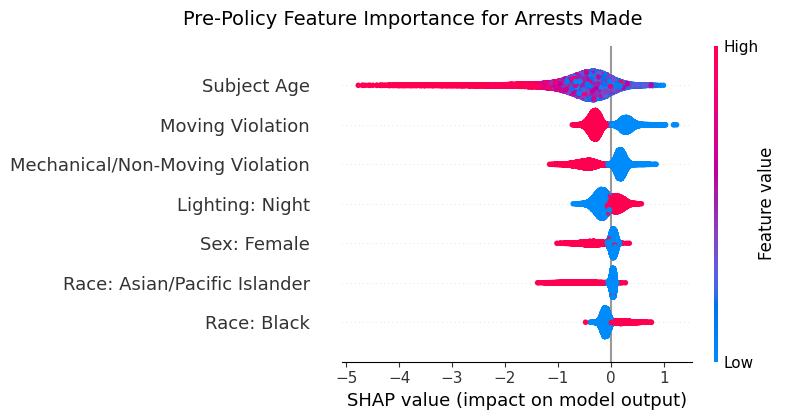

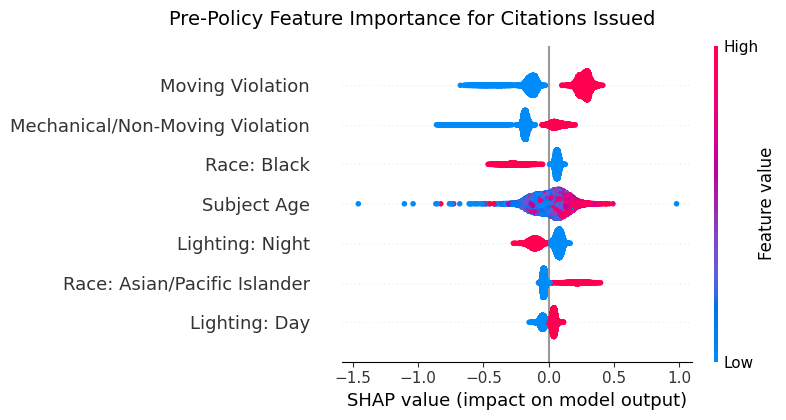

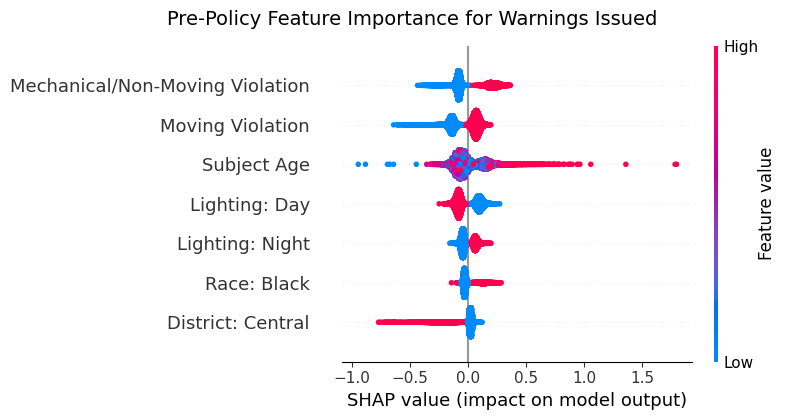

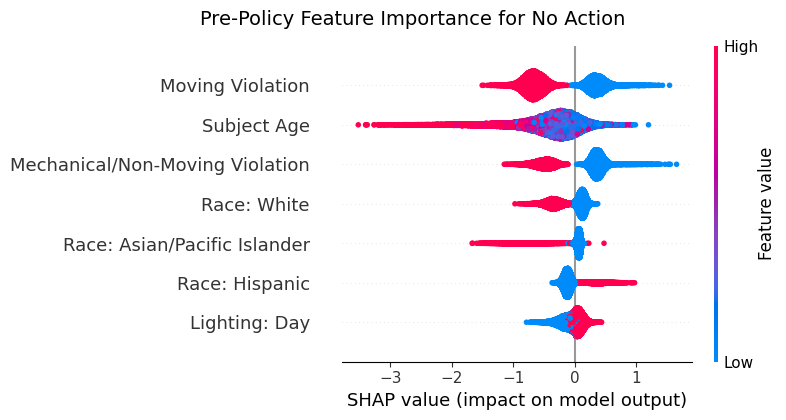

In [62]:
readable_feature_names = [
    feature_label_map.get(col, col) for col in X_val_prepolicy.columns
]

shap_values_per_class = [shap_values[:, :, i] for i in range(n_classes)]
class_names = ['Arrests Made', 'Citations Issued', 'Warnings Issued', 'No Action']

for i, class_name in enumerate(class_names):
    shap.summary_plot(
        shap_values_per_class[i],
        X_test_prepolicy,
        feature_names=readable_feature_names,
        max_display=7,
        show=False  
    )
    plt.title(f"Pre-Policy Feature Importance for {class_name}", fontsize=14, pad=15, x=0.2)
    plt.tight_layout()
    plt.show()

In [63]:
for i, class_name in enumerate(class_names):
    print(f"\n{'='*50}")
    print(f"Class: {class_name}")
    print(f"{'='*50}")
    
    # mean absolute shap value per feature = overall importance
    mean_abs_shap = np.abs(shap_values_per_class[i]).mean(axis=0)
    
    # mean raw shap value per feature = direction of effect
    mean_shap = shap_values_per_class[i].mean(axis=0)
    
    importance_df = pd.DataFrame({
        'Feature': readable_feature_names,
        'Mean |SHAP|': mean_abs_shap,   # magnitude — how important
        'Mean SHAP': mean_shap          # direction — positive pushes toward this class
    }).sort_values('Mean |SHAP|', ascending=False)
    
    print(importance_df.head(10).to_string(index=False))


Class: Arrests Made
                        Feature  Mean |SHAP|  Mean SHAP
                    Subject Age     0.577773  -0.541167
               Moving Violation     0.306497  -0.081412
Mechanical/Non-Moving Violation     0.292800  -0.052276
                Lighting: Night     0.174970  -0.074169
                    Sex: Female     0.145690  -0.074095
   Race: Asian/Pacific Islander     0.136551  -0.073199
                    Race: Black     0.124481  -0.055627
                      Sex: Male     0.101995  -0.035943
            District: Ingleside     0.098807  -0.042652
            Race: Other/Unknown     0.098671  -0.051522

Class: Citations Issued
                        Feature  Mean |SHAP|  Mean SHAP
               Moving Violation     0.223012   0.119074
Mechanical/Non-Moving Violation     0.140462  -0.096324
                    Race: Black     0.099396   0.009133
                    Subject Age     0.097665   0.017740
                Lighting: Night     0.087738   0.008005
  

Pre-Policy Test Set Accuracy: 0.6745376344086021


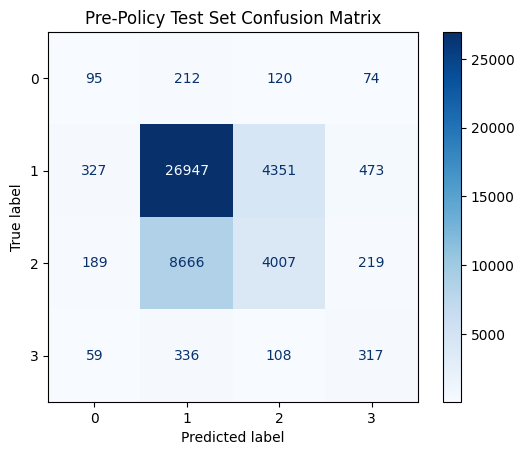

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# get final predictions
test_pre_preds = best_model_prepolicy.predict(X_test_prepolicy)

# Calculate the accuracy score
accuracy = accuracy_score(y_test_prepolicy, test_pre_preds)
print("Pre-Policy Test Set Accuracy:", accuracy)

# get confusion matrix
cm = confusion_matrix(y_test_prepolicy, test_pre_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Pre-Policy Test Set Confusion Matrix")
plt.show()


## Fit Model for Post Policy Data 

In [ ]:
# get weights
sample_weights_postpolicy = get_weights(y_train_postpolicy)

# get number of classes from data
n_classes = len(train_post['outcome'].unique())


In [ ]:
# tune parameters
def objective(trial):
    params = {
        "objective": "multi:softprob",
        "eval_metric": "mlogloss",
        "num_class": n_classes,
        "tree_method": "hist",
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 20.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
        "learning_rate": 0.1,
        "n_estimators": 1000,
        "early_stopping_rounds": 50,
    }

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train_postpolicy, y_train_postpolicy,
        eval_set=[(X_val_postpolicy, y_val_postpolicy)],
        sample_weight=sample_weights_postpolicy,
        verbose=False
    )
    return log_loss(y_val_postpolicy, model.predict_proba(X_val_postpolicy))


In [ ]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best log_loss:", study.best_value)
print("Best params:", study.best_params)

[I 2026-03-29 08:58:52,013] A new study created in memory with name: no-name-8260c856-f529-4f39-8add-0ed028e21f06
[I 2026-03-29 08:58:58,430] Trial 0 finished with value: 0.7170506310818208 and parameters: {'max_depth': 5, 'min_child_weight': 16, 'gamma': 0.511267239090003, 'subsample': 0.7035515842386952, 'colsample_bytree': 0.6554792266705943, 'reg_alpha': 0.05488112745426057, 'reg_lambda': 0.014458749305605525}. Best is trial 0 with value: 0.7170506310818208.
[I 2026-03-29 08:59:02,593] Trial 1 finished with value: 0.7326081535715171 and parameters: {'max_depth': 3, 'min_child_weight': 23, 'gamma': 4.002844270743104, 'subsample': 0.903044330882522, 'colsample_bytree': 0.5828130301510132, 'reg_alpha': 18.135040586856043, 'reg_lambda': 0.17493158606637685}. Best is trial 0 with value: 0.7170506310818208.
[I 2026-03-29 08:59:06,189] Trial 2 finished with value: 0.7292306435844059 and parameters: {'max_depth': 3, 'min_child_weight': 4, 'gamma': 4.169959538634925, 'subsample': 0.50755871

Best log_loss: 0.6913555075273372
Best params: {'max_depth': 10, 'min_child_weight': 5, 'gamma': 0.7017873912755576, 'subsample': 0.840502561647794, 'colsample_bytree': 0.6983514992087493, 'reg_alpha': 0.06585807176201207, 'reg_lambda': 0.03298765449069266}


## Get SHAP values from model results

In [64]:
import shap
# train final model with sqrt weights
# best_params = study.best_params
# best_params.update({
#     "objective": "multi:softprob",
#     "eval_metric": "mlogloss",
#     "num_class": n_classes,
#     "tree_method": "hist",
#     "learning_rate": 0.1,
#     "n_estimators": 1000,
#     "early_stopping_rounds": 50,
# })

# set manually
best_params = {
    # tuned params
    "max_depth": 10,
    "min_child_weight": 5,
    "gamma": 0.7017873912755576,
    "subsample": 0.840502561647794,
    "colsample_bytree": 0.6983514992087493,
    "reg_alpha": 0.06585807176201207,
    "reg_lambda": 0.03298765449069266,
    # fixed params
    "objective": "multi:softprob",
    "eval_metric": "mlogloss",
    "num_class": n_classes,
    "tree_method": "hist",
    "learning_rate": 0.1,
    "n_estimators": 1000,
    "early_stopping_rounds": 50,
}

n_classes = len(train_post['outcome'].unique())


best_model_postpolicy = xgb.XGBClassifier(**best_params)
best_model_postpolicy.fit(
    X_train_postpolicy, y_train_postpolicy,
    sample_weight=sample_weights_postpolicy,
    eval_set=[(X_val_postpolicy, y_val_postpolicy)],
    verbose=False
)

# get shap values
explainer = shap.TreeExplainer(best_model_postpolicy)
shap_values = explainer.shap_values(X_test_postpolicy)
print(f"Number of class explanations: {len(shap_values)}")
print(f"Shape per class: {shap_values[0].shape}")

Number of class explanations: 17842
Shape per class: (52, 4)


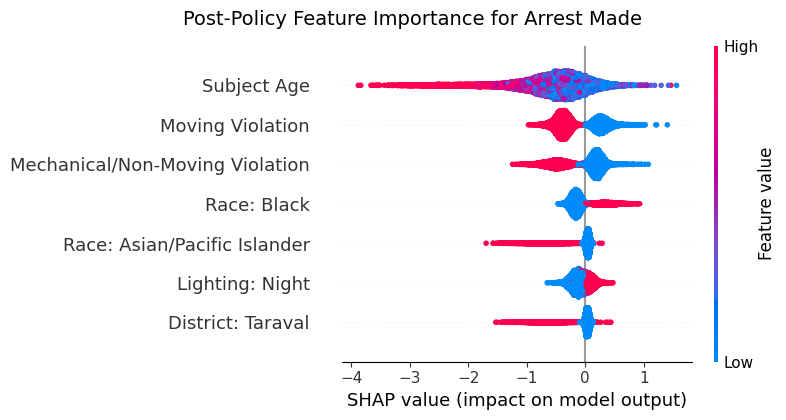

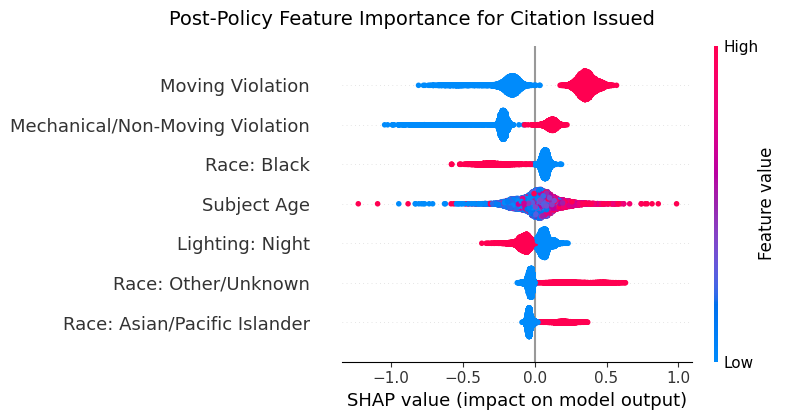

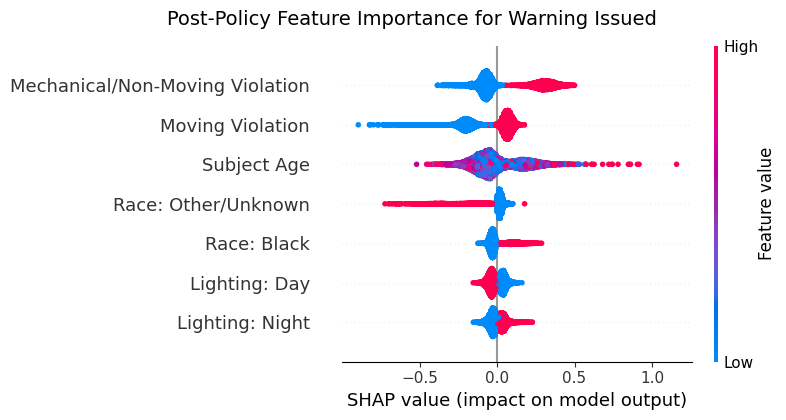

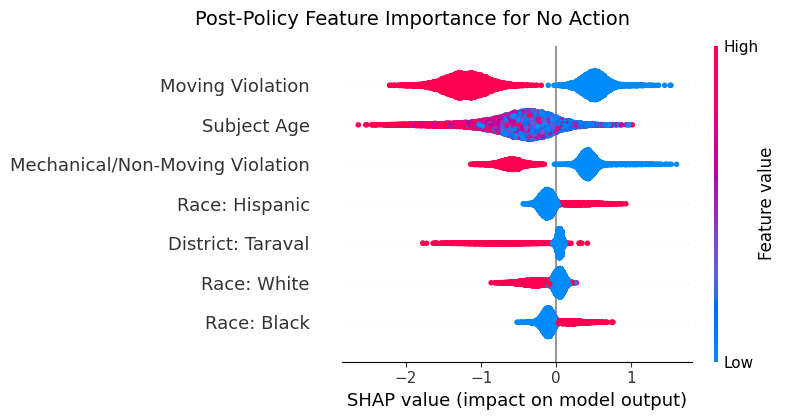

In [65]:
readable_feature_names = [
    feature_label_map.get(col, col) for col in X_val_postpolicy.columns
]

shap_values_per_class = [shap_values[:, :, i] for i in range(n_classes)]
class_names = ['Arrest Made', 'Citation Issued', 'Warning Issued', 'No Action']

for i, class_name in enumerate(class_names):
    shap.summary_plot(
        shap_values_per_class[i],
        X_test_postpolicy,
        feature_names=readable_feature_names,
        max_display=7,
        show=False  
    )
    plt.title(f"Post-Policy Feature Importance for {class_name}", fontsize=14, pad=15, x=0.2)
    plt.tight_layout()
    plt.show()


In [66]:
for i, class_name in enumerate(class_names):
    print(f"\n{'='*50}")
    print(f"Class: {class_name}")
    print(f"{'='*50}")
    
    # mean absolute shap value per feature = overall importance
    mean_abs_shap = np.abs(shap_values_per_class[i]).mean(axis=0)
    
    # mean raw shap value per feature = direction of effect
    mean_shap = shap_values_per_class[i].mean(axis=0)
    
    importance_df = pd.DataFrame({
        'Feature': readable_feature_names,
        'Mean |SHAP|': mean_abs_shap,   # magnitude — how important
        'Mean SHAP': mean_shap          # direction — positive pushes toward this class
    }).sort_values('Mean |SHAP|', ascending=False)
    
    print(importance_df.head(10).to_string(index=False))


Class: Arrest Made
                        Feature  Mean |SHAP|  Mean SHAP
                    Subject Age     0.642708  -0.583228
               Moving Violation     0.357964  -0.135529
Mechanical/Non-Moving Violation     0.310278  -0.052438
                    Race: Black     0.195166  -0.077989
   Race: Asian/Pacific Islander     0.157967  -0.081707
                Lighting: Night     0.133094  -0.067129
              District: Taraval     0.130029  -0.063588
                    Sex: Female     0.118600  -0.068114
             District: Richmond     0.099798  -0.061828
                        month_4     0.099171  -0.043890

Class: Citation Issued
                        Feature  Mean |SHAP|  Mean SHAP
               Moving Violation     0.292049   0.153497
Mechanical/Non-Moving Violation     0.189280  -0.104692
                    Race: Black     0.109430   0.010477
                    Subject Age     0.100776   0.025825
                Lighting: Night     0.072051   0.007450
    

Post-Policy Test Set Accuracy: 0.7005380562717184


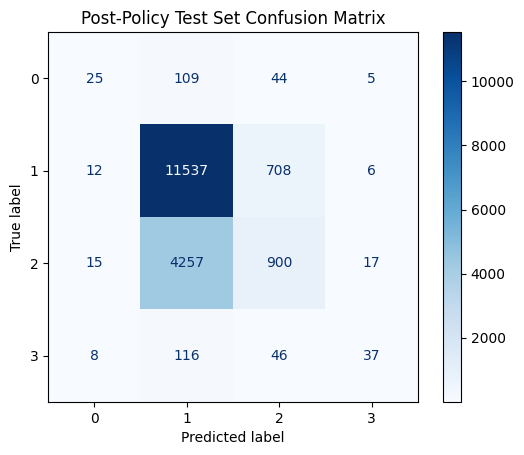

In [ ]:
# get final predictions
test_post_preds = best_model_postpolicy.predict(X_test_postpolicy)

# Calculate the accuracy score
accuracy = accuracy_score(y_test_post, test_post_preds)
print("Post-Policy Test Set Accuracy:", accuracy)

# get confusion matrix
cm = confusion_matrix(y_test_post, test_post_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Post-Policy Test Set Confusion Matrix")
plt.show()